# Agricultural Carbon Emissions Prediction Using Linear Regression

## Mission
To empower farmers and agricultural organizations with AI-driven insights that predict agricultural carbon emissions and recommend sustainable farming practices to reduce environmental impact while maintaining food production.

## Use Case
This project develops regression models to predict agricultural carbon emissions using production-related features from the Agri-Food CO₂ Emission Dataset. The predictions can help farmers and agricultural organizations estimate emissions and make informed decisions about sustainable farming practices.

## Dataset Source
https://www.kaggle.com/datasets/alessandrolobello/agri-food-co2-emission-dataset-forecasting-ml

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import joblib
import kagglehub

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [2]:
dataset_path = Path(
    kagglehub.dataset_download(
        "alessandrolobello/agri-food-co2-emission-dataset-forecasting-ml"
    )
)

100%|██████████| 706k/706k [00:01<00:00, 580kB/s]

Extracting files...


In [3]:
csv_files = list(dataset_path.glob("*.csv"))

csv_files

[WindowsPath('C:/Users/HP/.cache/kagglehub/datasets/alessandrolobello/agri-food-co2-emission-dataset-forecasting-ml/versions/1/Agrofood_co2_emission.csv')]

In [4]:
import os

os.listdir(dataset_path)

['Agrofood_co2_emission.csv']

In [5]:
df = pd.read_csv(dataset_path / "Agrofood_co2_emission.csv")

df.head()

,Area,Year,Savanna fires,Forest fires,Crop Residues,Rice Cultivation,Drained organic soils (CO2),Pesticides Manufacturing,Food Transport,Forestland,Net Forest conversion,Food Household Consumption,Food Retail,On-farm Electricity Use,Food Packaging,Agrifood Systems Waste Disposal,Food Processing,Fertilizers Manufacturing,IPPU,Manure applied to Soils,Manure left on Pasture,Manure Management,Fires in organic soils,Fires in humid tropical forests,On-farm energy use,Rural population,Urban population,Total Population - Male,Total Population - Female,total_emission,Average Temperature °C
0,Afghanistan,1990,14.7237,0.0557,205.6077,686.00,0.0,11.807483,63.1152,-2388.803,0.0,79.0851,109.6446,14.2666,67.631366,691.7888,252.21419,11.9970,209.9778,260.1431,1590.5319,319.1763,0.0,0.0,NaN,9655167.0,2593947.0,5348387.0,5346409.0,2198.963539,0.536167
1,Afghanistan,1991,14.7237,0.0557,209.4971,678.16,0.0,11.712073,61.2125,-2388.803,0.0,80.4885,116.6789,11.4182,67.631366,710.8212,252.21419,12.8539,217.0388,268.6292,1657.2364,342.3079,0.0,0.0,NaN,10230490.0,2763167.0,5372959.0,5372208.0,2323.876629,0.020667
2,Afghanistan,1992,14.7237,0.0557,196.5341,686.00,0.0,11.712073,53.3170,-2388.803,0.0,80.7692,126.1721,9.2752,67.631366,743.6751,252.21419,13.4929,222.1156,264.7898,1653.5068,349.1224,0.0,0.0,NaN,10995568.0,2985663.0,6028494.0,6028939.0,2356.304229,-0.259583
3,Afghanistan,1993,14.7237,0.0557,230.8175,686.00,0.0,11.712073,54.3617,-2388.803,0.0,85.0678,81.4607,9.0635,67.631366,791.9246,252.21419,14.0559,201.2057,261.7221,1642.9623,352.2947,0.0,0.0,NaN,11858090.0,3237009.0,7003641.0,7000119.0,2368.470529,0.101917
4,Afghanistan,1994,14.7237,0.0557,242.0494,705.60,0.0,11.712073,53.9874,-2388.803,0.0,88.8058,90.4008,8.3962,67.631366,831.9181,252.21419,15.1269,182.2905,267.6219,1689.3593,367.6784,0.0,0.0,NaN,12690115.0,3482604.0,7733458.0,7722096.0,2500.768729,0.372250


In [6]:
numeric_columns = df.select_dtypes(include=np.number).columns

df[numeric_columns] = df[numeric_columns].fillna(
    df[numeric_columns].median()
)

df.isnull().sum().sort_values(ascending=False)

Area                               0
Year                               0
Savanna fires                      0
Forest fires                       0
Crop Residues                      0
Rice Cultivation                   0
Drained organic soils (CO2)        0
Pesticides Manufacturing           0
Food Transport                     0
Forestland                         0
Net Forest conversion              0
Food Household Consumption         0
Food Retail                        0
On-farm Electricity Use            0
Food Packaging                     0
Agrifood Systems Waste Disposal    0
Food Processing                    0
Fertilizers Manufacturing          0
IPPU                               0
Manure applied to Soils            0
Manure left on Pasture             0
Manure Management                  0
Fires in organic soils             0
Fires in humid tropical forests    0
On-farm energy use                 0
Rural population                   0
Urban population                   0
T

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.shape

df.info()

df.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 6965 entries, 0 to 6964
Data columns (total 31 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Area                             6965 non-null   str    
 1   Year                             6965 non-null   int64  
 2   Savanna fires                    6965 non-null   float64
 3   Forest fires                     6965 non-null   float64
 4   Crop Residues                    6965 non-null   float64
 5   Rice Cultivation                 6965 non-null   float64
 6   Drained organic soils (CO2)      6965 non-null   float64
 7   Pesticides Manufacturing         6965 non-null   float64
 8   Food Transport                   6965 non-null   float64
 9   Forestland                       6965 non-null   float64
 10  Net Forest conversion            6965 non-null   float64
 11  Food Household Consumption       6965 non-null   float64
 12  Food Retail                    

,Area,Year,Savanna fires,Forest fires,Crop Residues,Rice Cultivation,Drained organic soils (CO2),Pesticides Manufacturing,Food Transport,Forestland,Net Forest conversion,Food Household Consumption,Food Retail,On-farm Electricity Use,Food Packaging,Agrifood Systems Waste Disposal,Food Processing,Fertilizers Manufacturing,IPPU,Manure applied to Soils,Manure left on Pasture,Manure Management,Fires in organic soils,Fires in humid tropical forests,On-farm energy use,Rural population,Urban population,Total Population - Male,Total Population - Female,total_emission,Average Temperature °C
count,6965,6965.000000,6965.000000,6965.000000,6965.000000,6965.000000,6965.000000,6965.000000,6965.000000,6965.000000,6.965000e+03,6965.000000,6965.000000,6965.000000,6965.000000,6965.000000,6965.000000,6965.000000,6.965000e+03,6965.000000,6965.000000,6965.000000,6965.000000,6965.000000,6965.000000,6.965000e+03,6.965000e+03,6.965000e+03,6.965000e+03,6.965000e+03,6965.000000
unique,236,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2005.124910,1183.108924,907.034122,820.218691,4259.666673,3503.228636,333.418393,1939.581760,-16570.808969,1.636262e+04,4528.934628,2043.210539,1626.681460,1658.629808,6018.444633,3872.724461,3035.723356,1.794462e+04,816.264882,3518.026573,1997.737270,1210.315532,653.577094,2615.342773,1.785774e+07,1.693230e+07,1.761963e+07,1.732447e+07,6.409124e+04,0.872989
std,NaN,8.894665,5235.194053,3696.660308,3330.078734,17613.825187,15861.445678,1429.159367,5616.748808,79013.974879,9.761518e+04,24925.910145,8494.249260,9343.182193,11481.343725,22156.742542,19838.216846,11693.029064,1.054759e+05,3016.661673,9103.556202,7460.634391,22669.847760,3229.846962,11779.828918,8.901521e+07,6.574362e+07,7.603993e+07,7.251711e+07,2.283130e+05,0.555930
min,NaN,1990.000000,0.000000,0.000000,0.000200,0.000000,0.000000,0.000000,0.000100,-797183.079000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.340000,0.000100,0.001900,0.000000e+00,0.049000,0.000700,0.432900,0.000000,0.000000,0.031900,0.000000e+00,0.000000e+00,2.500000e+02,2.700000e+02,-3.918841e+05,-1.415833
25%,NaN,1997.000000,0.000000,0.000000,25.360100,181.260800,0.000000,6.000000,27.958600,-2299.387200,0.000000e+00,13.797400,26.818500,8.037600,67.631366,86.680500,209.587728,360.358799,5.193070e+01,23.119500,139.669900,52.707800,0.000000,0.000000,17.738200,9.731100e+04,2.173860e+05,2.013260e+05,2.078900e+05,5.221244e+03,0.511333
50%,NaN,2005.000000,1.651850,0.517900,103.698200,534.817400,0.000000,13.000000,204.962800,-62.920000,4.444000e+01,155.471100,172.042600,29.120700,74.018133,901.275700,344.760200,1115.052400,8.037066e+02,120.443900,972.567400,269.856300,0.000000,0.000000,141.096300,1.595322e+06,2.357581e+06,2.469660e+06,2.444135e+06,1.214765e+04,0.834300
75%,NaN,2013.000000,108.361700,61.237200,264.718000,1536.640000,690.408800,116.325487,1207.000900,0.000000,3.830905e+03,1238.668800,1075.999100,499.944700,281.791000,3006.442100,1236.913400,2024.869900,4.990590e+03,379.964800,2430.792600,883.170300,0.000000,6.941800,845.713100,8.177340e+06,8.277123e+06,9.075924e+06,9.112588e+06,3.513973e+04,1.206750


In [9]:
missing_values = df.isnull().sum().sort_values(ascending=False)

duplicates = df.duplicated().sum()

missing_values

duplicates

np.int64(0)

In [10]:
pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values
})

,Column,Data Type
0,Area,str
1,Year,int64
2,Savanna fires,float64
3,Forest fires,float64
4,Crop Residues,float64
5,Rice Cultivation,float64
6,Drained organic soils (CO2),float64
7,Pesticides Manufacturing,float64
8,Food Transport,float64
9,Forestland,float64


In [11]:
target = "total_emission"

X = df.drop(columns=[target])
y = df[target]

X.head()

,Area,Year,Savanna fires,Forest fires,Crop Residues,Rice Cultivation,Drained organic soils (CO2),Pesticides Manufacturing,Food Transport,Forestland,Net Forest conversion,Food Household Consumption,Food Retail,On-farm Electricity Use,Food Packaging,Agrifood Systems Waste Disposal,Food Processing,Fertilizers Manufacturing,IPPU,Manure applied to Soils,Manure left on Pasture,Manure Management,Fires in organic soils,Fires in humid tropical forests,On-farm energy use,Rural population,Urban population,Total Population - Male,Total Population - Female,Average Temperature °C
0,Afghanistan,1990,14.7237,0.0557,205.6077,686.00,0.0,11.807483,63.1152,-2388.803,0.0,79.0851,109.6446,14.2666,67.631366,691.7888,252.21419,11.9970,209.9778,260.1431,1590.5319,319.1763,0.0,0.0,141.0963,9655167.0,2593947.0,5348387.0,5346409.0,0.536167
1,Afghanistan,1991,14.7237,0.0557,209.4971,678.16,0.0,11.712073,61.2125,-2388.803,0.0,80.4885,116.6789,11.4182,67.631366,710.8212,252.21419,12.8539,217.0388,268.6292,1657.2364,342.3079,0.0,0.0,141.0963,10230490.0,2763167.0,5372959.0,5372208.0,0.020667
2,Afghanistan,1992,14.7237,0.0557,196.5341,686.00,0.0,11.712073,53.3170,-2388.803,0.0,80.7692,126.1721,9.2752,67.631366,743.6751,252.21419,13.4929,222.1156,264.7898,1653.5068,349.1224,0.0,0.0,141.0963,10995568.0,2985663.0,6028494.0,6028939.0,-0.259583
3,Afghanistan,1993,14.7237,0.0557,230.8175,686.00,0.0,11.712073,54.3617,-2388.803,0.0,85.0678,81.4607,9.0635,67.631366,791.9246,252.21419,14.0559,201.2057,261.7221,1642.9623,352.2947,0.0,0.0,141.0963,11858090.0,3237009.0,7003641.0,7000119.0,0.101917
4,Afghanistan,1994,14.7237,0.0557,242.0494,705.60,0.0,11.712073,53.9874,-2388.803,0.0,88.8058,90.4008,8.3962,67.631366,831.9181,252.21419,15.1269,182.2905,267.6219,1689.3593,367.6784,0.0,0.0,141.0963,12690115.0,3482604.0,7733458.0,7722096.0,0.372250


In [12]:
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(exclude=["object"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numerical_features),
    ]
)

X_processed = preprocessor.fit_transform(X)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y,
    test_size=0.2,
    random_state=42,
)

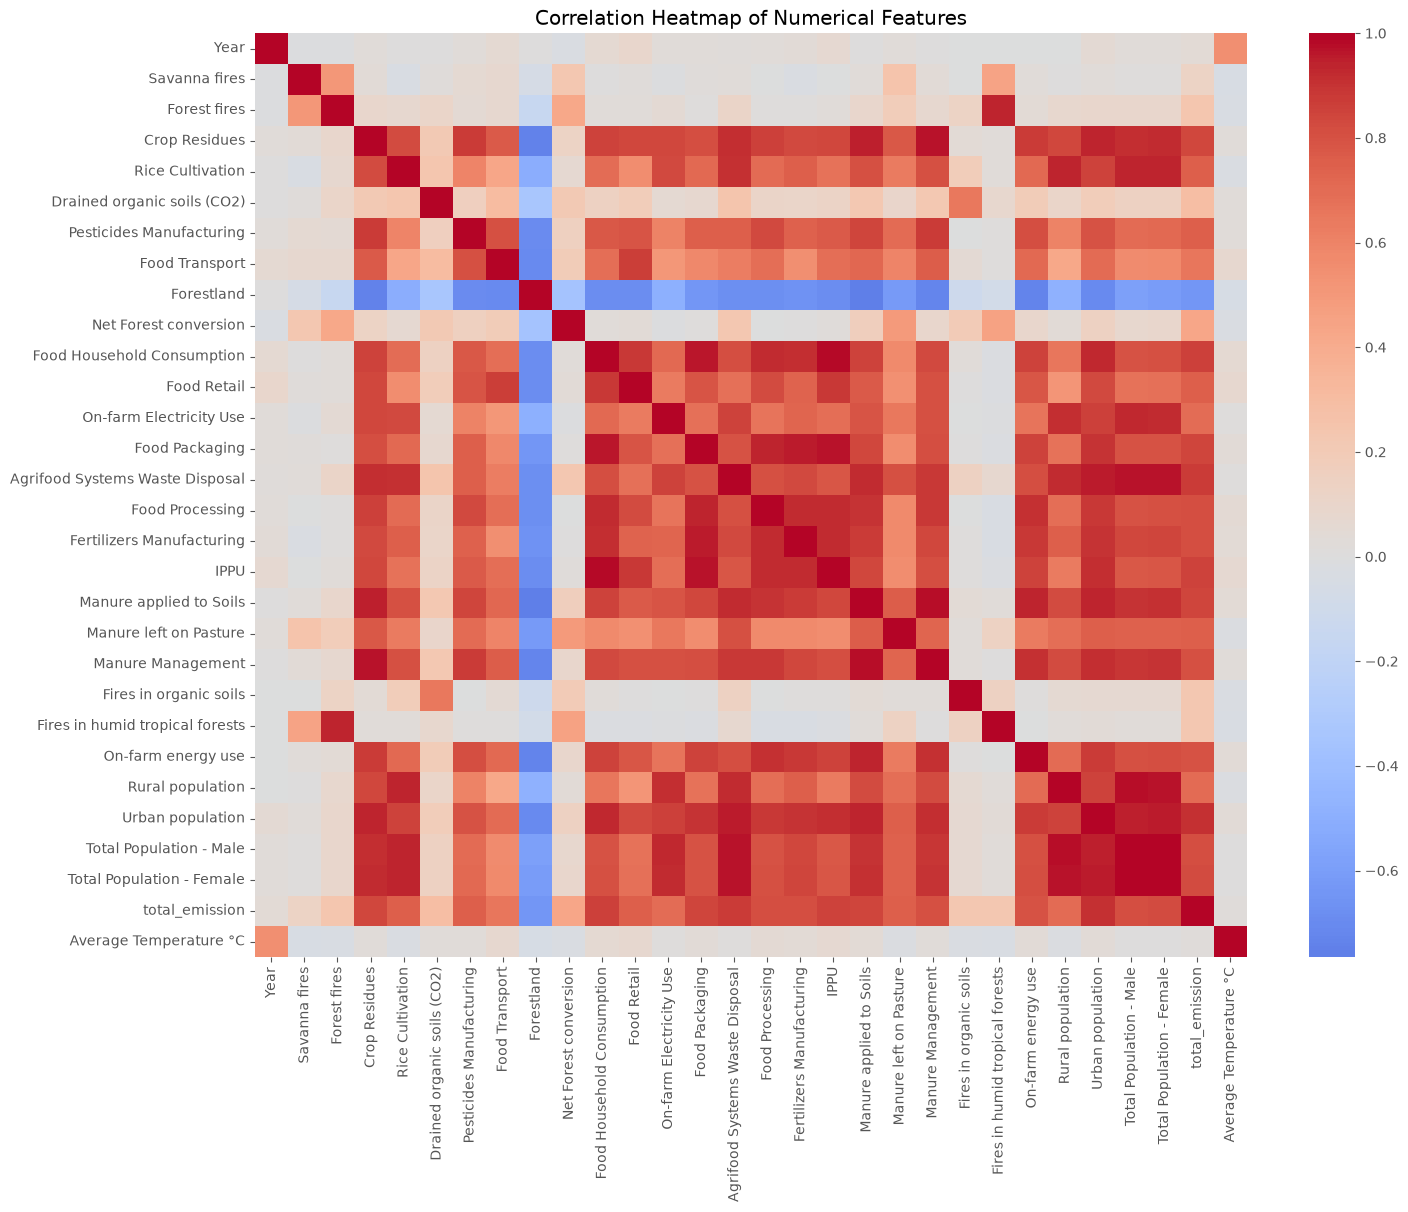

In [14]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    cmap="coolwarm",
    center=0,
)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

### Interpretation

The heatmap shows the relationships between the numerical variables and total agricultural carbon emissions. Variables with stronger positive correlations are expected to contribute more significantly to the prediction of total emissions, while negatively correlated variables indicate an inverse relationship. This visualization helps identify the most influential predictors before model training.

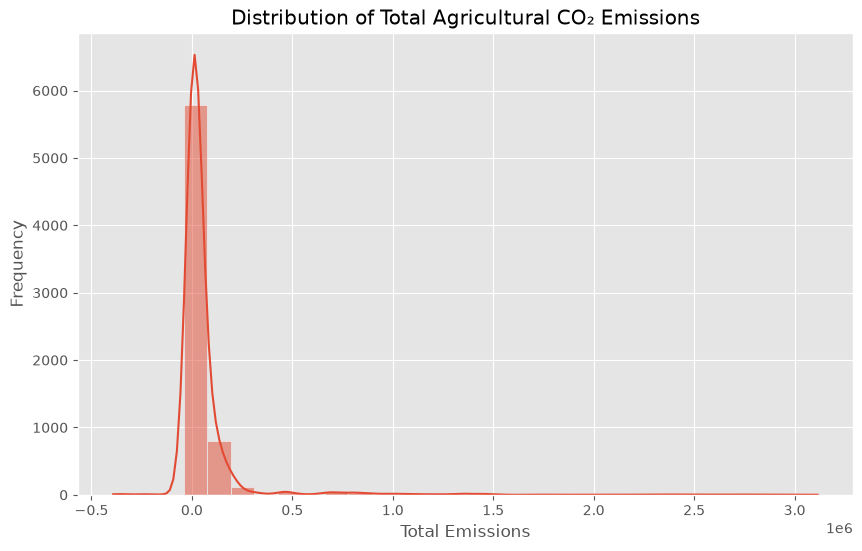

In [15]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["total_emission"],
    bins=30,
    kde=True
)

plt.title("Distribution of Total Agricultural CO₂ Emissions")
plt.xlabel("Total Emissions")
plt.ylabel("Frequency")

plt.show()

### Interpretation

The distribution of total agricultural carbon emissions illustrates how emission values are spread across the dataset. Understanding this distribution helps determine whether the target variable is normally distributed or skewed, which can influence the performance of regression models. The visualization also helps identify potential outliers that may affect model accuracy.

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "SGD Regressor": SGDRegressor(
        max_iter=5000,
        learning_rate="adaptive",
        eta0=0.01,
        random_state=42,
    ),
    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),
    "Random Forest": RandomForestRegressor(
        random_state=42
    ),
}

trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model

In [ ]:
results = []

for name, model in trained_models.items():

    predictions = model.predict(X_test)

    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, predictions),
        "RMSE": np.sqrt(mean_squared_error(y_test, predictions)),
        "R² Score": r2_score(y_test, predictions),
    })

results = (
    pd.DataFrame(results)
    .sort_values("R² Score", ascending=False)
    .reset_index(drop=True)
)

results

,Model,MAE,RMSE,R² Score
0,Linear Regression,5.058122e+00,1.715825e+01,1.000000e+00
1,Random Forest,3.326763e+03,2.534539e+04,9.907134e-01
2,Decision Tree,4.452019e+03,3.174944e+04,9.854276e-01
3,SGD Regressor,3.090175e+09,5.301383e+09,-4.062920e+08


In [ ]:
best_model_name = results.loc[0, "Model"]

best_model = trained_models[best_model_name]

best_model_name

'Linear Regression'

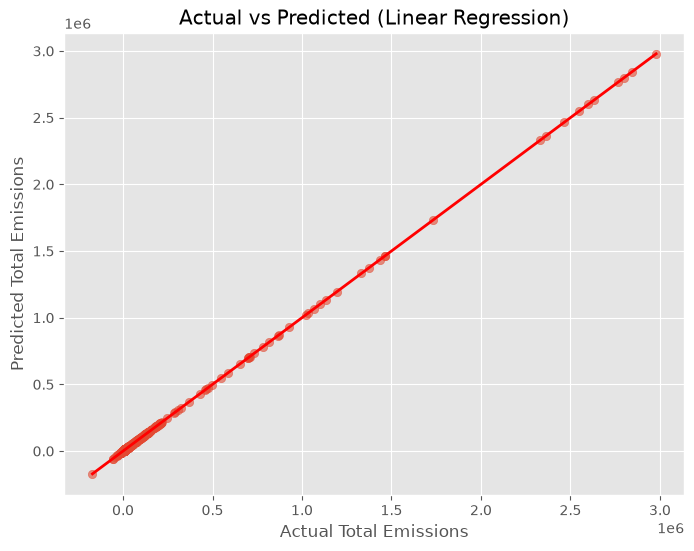

In [ ]:
best_predictions = best_model.predict(X_test)

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.6
)

min_value = min(y_test.min(), best_predictions.min())
max_value = max(y_test.max(), best_predictions.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Total Emissions")
plt.ylabel("Predicted Total Emissions")
plt.title(f"Actual vs Predicted ({best_model_name})")

plt.show()

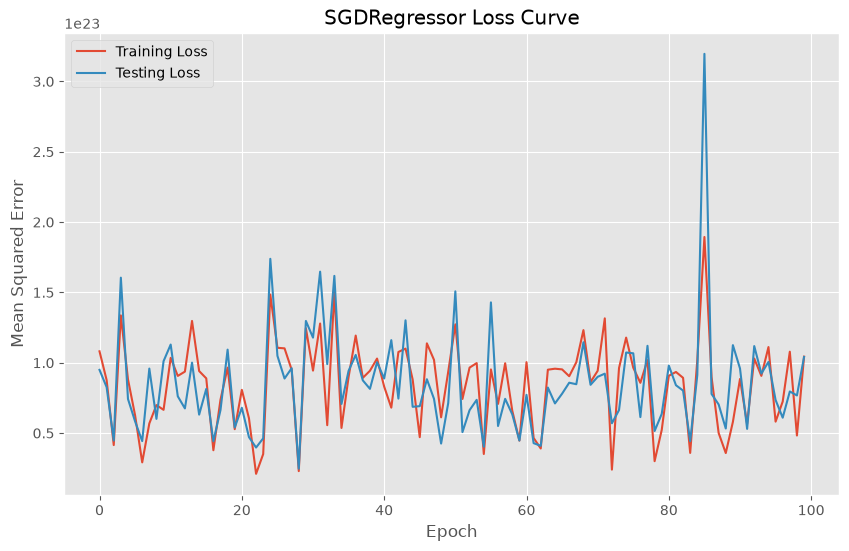

In [ ]:
sgd = SGDRegressor(
    learning_rate="adaptive",
    eta0=0.01,
    random_state=42,
)

train_loss = []
test_loss = []

for _ in range(100):

    sgd.partial_fit(X_train, y_train)

    train_predictions = sgd.predict(X_train)
    test_predictions = sgd.predict(X_test)

    train_loss.append(
        mean_squared_error(y_train, train_predictions)
    )

    test_loss.append(
        mean_squared_error(y_test, test_predictions)
    )

plt.figure(figsize=(10, 6))

plt.plot(train_loss, label="Training Loss")
plt.plot(test_loss, label="Testing Loss")

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("SGDRegressor Loss Curve")

plt.legend()

plt.show()

In [ ]:
MODEL_DIR = Path("models")

MODEL_DIR.mkdir(exist_ok=True)

joblib.dump(best_model, MODEL_DIR / "best_model.pkl")
joblib.dump(preprocessor, MODEL_DIR / "preprocessor.pkl")

list(MODEL_DIR.iterdir())

[WindowsPath('models/best_model.pkl'), WindowsPath('models/preprocessor.pkl')]

In [ ]:
sample = X_test[0].reshape(1, -1)

prediction = best_model.predict(sample)

actual_value = y_test.iloc[0]

pd.DataFrame(
    {
        "Actual Emission": [actual_value],
        "Predicted Emission": [prediction[0]],
    }
)

,Actual Emission,Predicted Emission
0,9797.21291,9799.190914
